# Imports

In [341]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC


# Data Inspection

In [306]:
df = pd.read_csv('C:\\Users\\Mafalda\\Desktop\\Mafalda brinca na areia\\chronic-kidney-disease-classifier\\kidney_disease .csv')
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [307]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [309]:
df.duplicated().sum()

np.int64(0)

In [310]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


Missing as numeric variables.
pcv: Packed cell volume (hematocrit, %).
wc: White blood cell count (cells/mm³).
rc: Red blood cell count (millions/mm³).

In [311]:
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce').astype('Int64')
df['wc'] = pd.to_numeric(df['wc'], errors='coerce').astype('Int64')
df['rc'] = pd.to_numeric(df['rc'], errors='coerce').astype('Float64')


In [312]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.0,294.0,269.0
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.47419,1.025323
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.0,2200.0,2.1
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.0,6500.0,3.9
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.0,8000.0,4.8
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.0,9800.0,5.4
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.0,26400.0,8.0


In [313]:
df = df.drop(labels="id", axis=1)

## Classification wording cleaning

In [314]:
for col in df.select_dtypes(include=["object", "category"]).columns:
    print(col, df[col].unique())
    df[col] = df[col].str.strip()
    print(col, df[col].unique())



rbc [nan 'normal' 'abnormal']
rbc [nan 'normal' 'abnormal']
pc ['normal' 'abnormal' nan]
pc ['normal' 'abnormal' nan]
pcc ['notpresent' 'present' nan]
pcc ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
htn ['yes' 'no' nan]
htn ['yes' 'no' nan]
dm ['yes' 'no' ' yes' '\tno' '\tyes' nan]
dm ['yes' 'no' nan]
cad ['no' 'yes' '\tno' nan]
cad ['no' 'yes' nan]
appet ['good' 'poor' nan]
appet ['good' 'poor' nan]
pe ['no' 'yes' nan]
pe ['no' 'yes' nan]
ane ['no' 'yes' nan]
ane ['no' 'yes' nan]
classification ['ckd' 'ckd\t' 'notckd']
classification ['ckd' 'notckd']


## Exploratory Data Analysis

In [315]:
X = df.drop(labels="classification", axis=1)
y = df["classification"].map({
    "notckd": 0,
    "ckd": 1
})

In [316]:
y.isnull().sum()

np.int64(0)

In [317]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

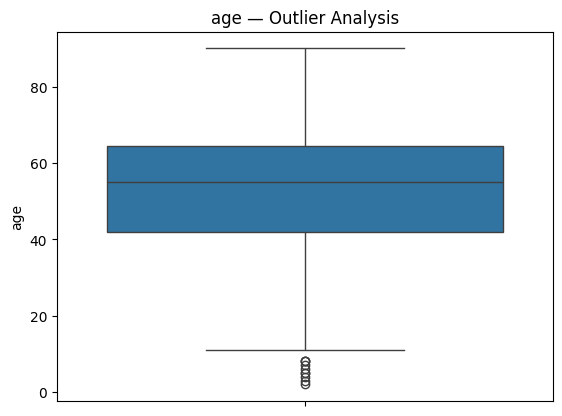

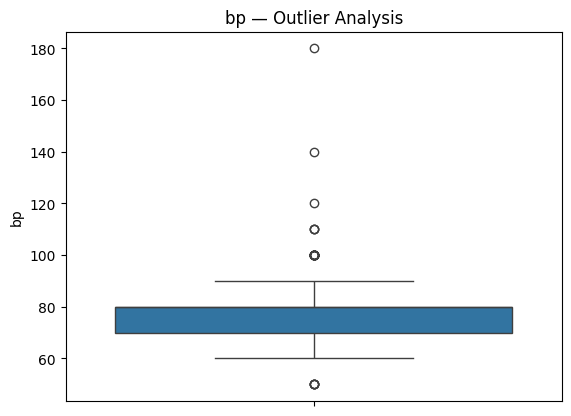

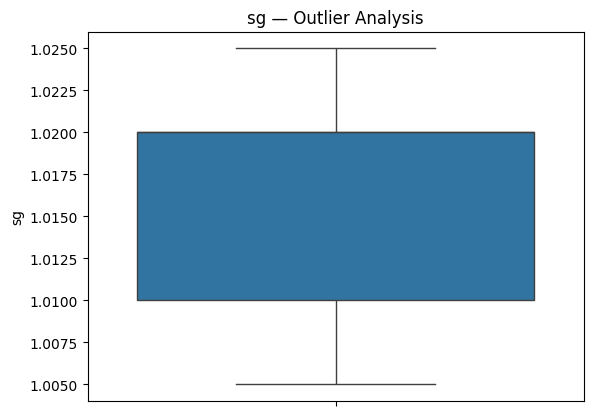

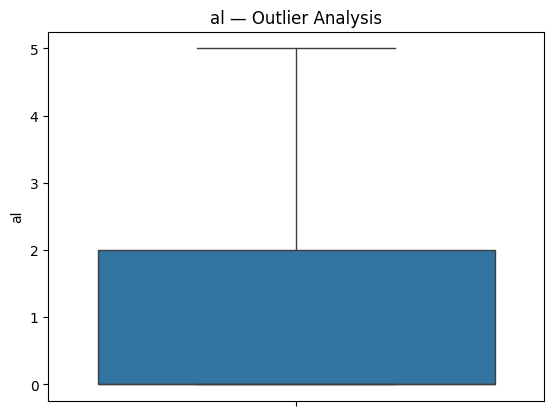

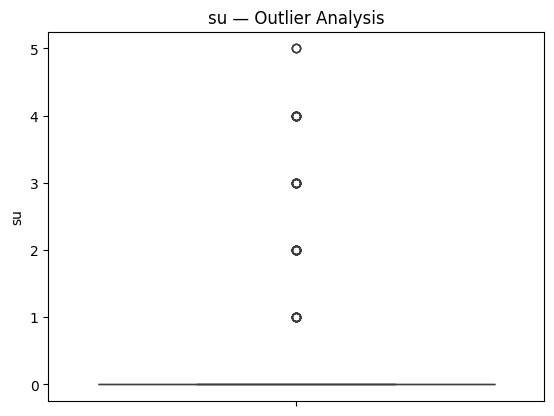

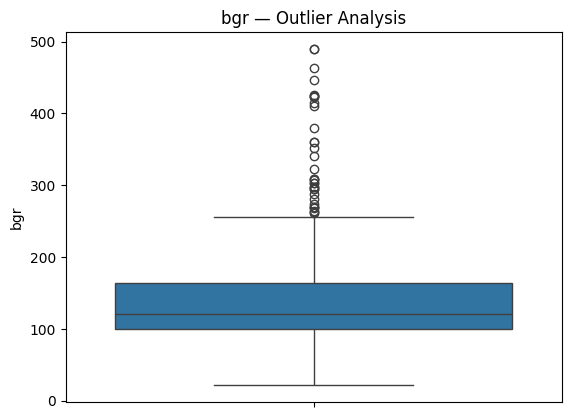

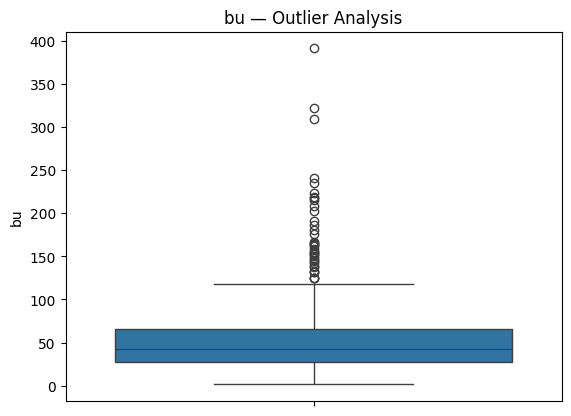

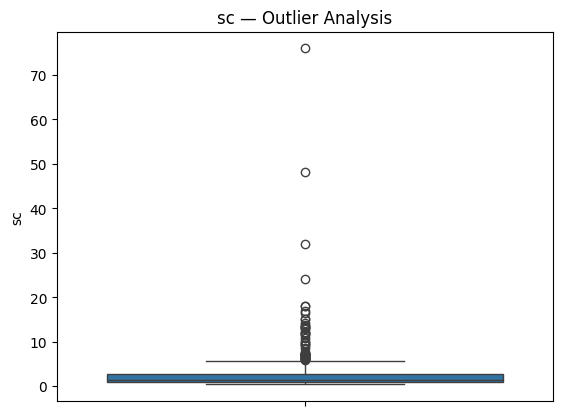

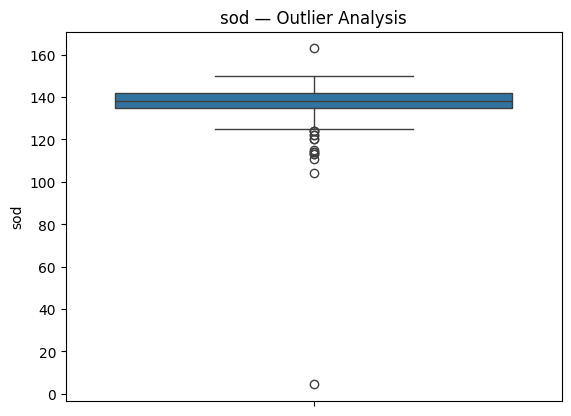

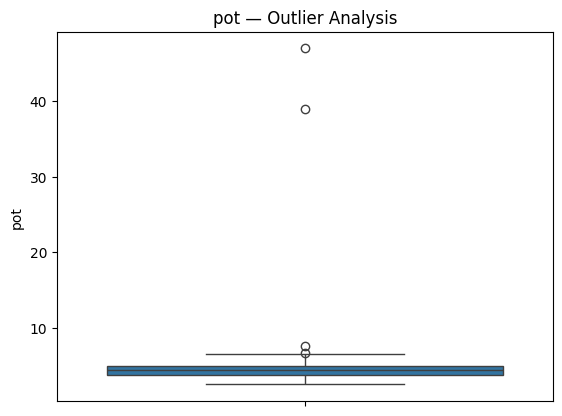

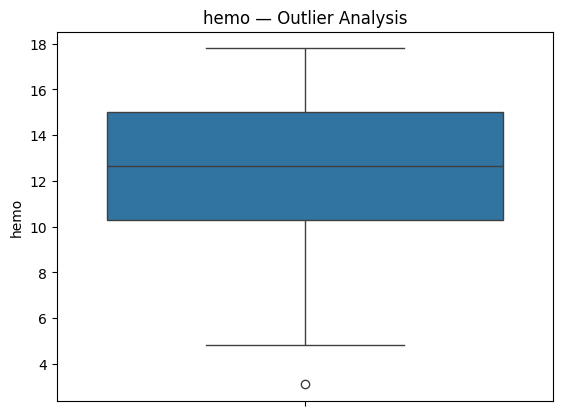

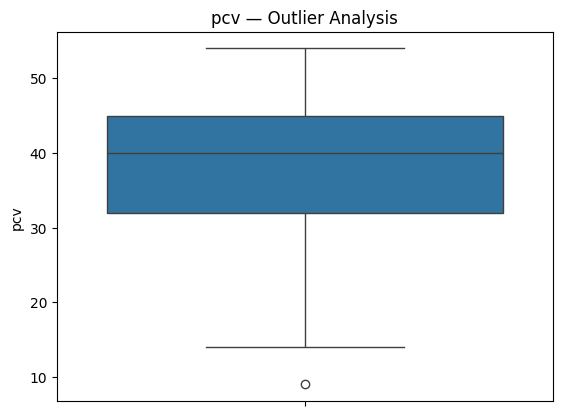

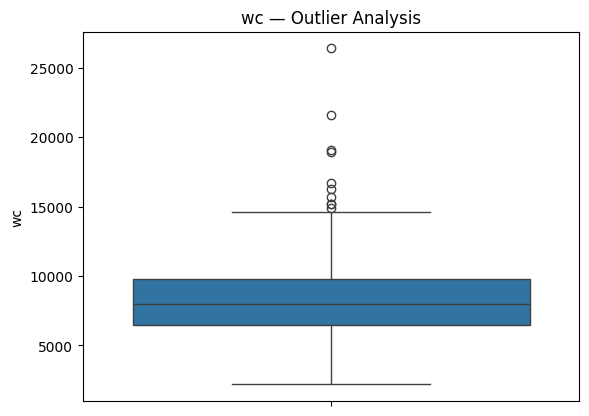

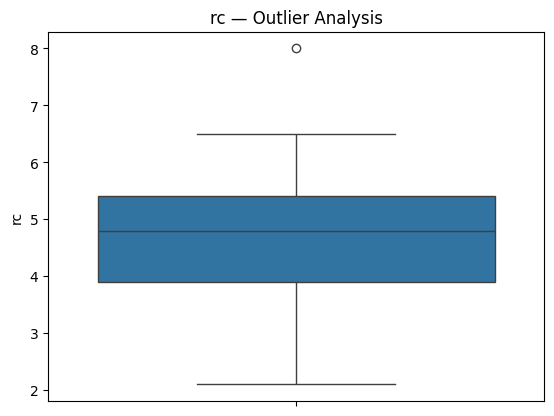

In [318]:
def visualize_outliers(data, target_c):
    """
    Visualize potential outliers using the IQR method.
    No observations are removed or capped.

    Parameters:
    - data: DataFrame
    - target_c: str
        The target column to exclude from visualization.
    """
    
    for c in num_cols:
        if c == target_c:
            continue

        sns.boxplot(data[c])
        plt.title(f"{c} — Outlier Analysis")
        plt.show()


visualize_outliers(df, target_c="classification")

## Analise unplausible phisiological values outside ranges.

In [319]:
plausible_ranges = {
    "age": (1, 100),
    "bp": (40, 250),
    "sg": (1.005, 1.025),
    "al": (0, 4),
    "su": (0, 5),
    "bgr": (30, 700),
    "bu": (2, 300),
    "sc": (0.2, 30),
    "sod": (100, 180),
    "pot": (2, 10),
    "hemo": (3, 22),
    "pcv": (10, 65),
    "wc": (1000, 50000),
    "rc": (1, 8)
}

for column, (min_val, max_val) in plausible_ranges.items():
    rows_outside_ranges = df[(df[column] < min_val) | (df[column] > max_val)]
    if not rows_outside_ranges.empty:
        print(f'{column} : min {min_val} - max {max_val}')
        display(rows_outside_ranges)

al : min 0 - max 4


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
145,57.0,90.0,1.015,5.0,0.0,abnormal,abnormal,notpresent,present,NaN,...,24,4200,3.3,yes,yes,yes,poor,yes,yes,ckd


bgr : min 30 - max 700


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
173,17.0,70.0,1.015,1.0,0.0,abnormal,normal,notpresent,notpresent,22.0,...,41,11200,<NA>,no,no,no,good,no,no,ckd


bu : min 2 - max 300


...

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
21,60.0,90.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,NaN,...,32,6200,3.6,yes,yes,yes,good,no,no,ckd


pot : min 2 - max 10


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
61,67.0,80.0,1.010,1.0,3.0,normal,abnormal,notpresent,notpresent,182.0,...,<NA>,<NA>,<NA>,no,no,no,good,yes,no,ckd
128,52.0,90.0,1.015,4.0,3.0,normal,abnormal,notpresent,notpresent,224.0,...,23,5000,2.9,yes,yes,no,good,no,yes,ckd


pcv : min 10 - max 65


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
249,56.0,90.0,1.01,4.0,1.0,normal,abnormal,present,notpresent,176.0,...,9,5400,2.1,yes,yes,no,poor,yes,yes,ckd


Skew:  -0.6682594691593559


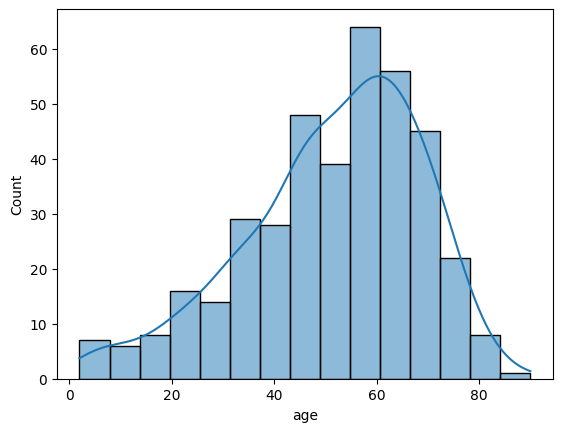

In [320]:
sns.histplot(data=X, x="age", kde=True)
print("Skew: ", X["age"].skew())

From the Clinical Measurements, seams like 5 is a mistake, since its outside feature range - al: Urine albumin level (0–4, ordinal scale).

- Since age column is moderately skewed (-0.67), will use median as the imputer.

I will apply the same rule for the rest of the numeric features, since this dataset has a considerably amount of features.
 - roughly symmetric (skew between -0.5 and 0.5) → mean
 - noticeably skewed or with outliers → median

### Inspecting Null Values/Feature

In [321]:
null_table_num = pd.DataFrame({
    "Feature": num_cols,
    "Null Count": df[num_cols].isnull().sum().values,
    "Null Percentage": (df[num_cols].isnull().mean().values * 100).round(2)
})

null_table_cat = pd.DataFrame({
    "Feature": cat_cols,
    "Null Count": df[cat_cols].isnull().sum().values,
    "Null Percentage": (df[cat_cols].isnull().mean().values * 100).round(2)
})

display(null_table_num.sort_values(by="Null Percentage", ascending=False))
display(null_table_cat.sort_values(by="Null Percentage", ascending=False))


,Feature,Null Count,Null Percentage
13,rc,131,32.75
12,wc,106,26.50
9,pot,88,22.00
8,sod,87,21.75
11,pcv,71,17.75
10,hemo,52,13.00
4,su,49,12.25
2,sg,47,11.75
3,al,46,11.50
5,bgr,44,11.00


,Feature,Null Count,Null Percentage
0,rbc,152,38.00
1,pc,65,16.25
2,pcc,4,1.00
3,ba,4,1.00
4,htn,2,0.50
5,dm,2,0.50
6,cad,2,0.50
7,appet,1,0.25
8,pe,1,0.25
9,ane,1,0.25


Features from 20-40% missing values will be later analysed according with model performance
Most frquest imputation will be used for Null Percentage <20%, and constant "unknown" for >20%

In [322]:
X[X.isna().sum(axis=1) > 6] # Counts of Nan per row greater than 6

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
13,68.0,70.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,98.0,...,9.8,<NA>,<NA>,<NA>,yes,yes,yes,poor,yes,no
17,47.0,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,114.0,...,12.1,<NA>,<NA>,<NA>,yes,no,no,poor,no,no
21,60.0,90.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,NaN,...,10.9,32,6200,3.6,yes,yes,yes,good,no,no
23,21.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,NaN,<NA>,<NA>,<NA>,no,no,no,poor,no,yes
28,75.0,70.0,NaN,1.0,3.0,NaN,NaN,notpresent,notpresent,123.0,...,NaN,<NA>,<NA>,<NA>,no,yes,no,good,no,no
30,NaN,70.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,93.0,...,NaN,<NA>,<NA>,<NA>,yes,yes,no,good,no,no
34,70.0,70.0,1.010,1.0,0.0,normal,NaN,present,present,171.0,...,NaN,<NA>,<NA>,<NA>,no,yes,no,poor,no,no
41,45.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,NaN,<NA>,<NA>,<NA>,no,no,no,good,yes,no
55,35.0,80.0,1.005,3.0,0.0,abnormal,normal,notpresent,notpresent,NaN,...,9.5,28,<NA>,<NA>,no,no,no,good,yes,no
57,76.0,90.0,NaN,NaN,NaN,NaN,normal,notpresent,notpresent,93.0,...,NaN,<NA>,<NA>,<NA>,yes,yes,yes,poor,no,no


The rows that have more missing values (>25% of features are missing) are classified as cdk. For now I will keep them since dataset is short.

# Data Preprocessing

### Handling Outliers

In [323]:
# Capping data to clinical limits since dataset is short
for column, (min_val, max_val) in plausible_ranges.items():
    X[column] = X[column].clip(lower=min_val, upper=max_val)


### Handling Missing Data

In [324]:
skewness = X[num_cols].skew()

mean_cols = skewness[skewness.abs() <= 0.5].index
median_cols = skewness[skewness.abs() > 0.5].index


In [325]:
most_frequent_cols = null_table_cat[null_table_cat["Null Percentage"] < 20]["Feature"]
constant_cols = null_table_cat[null_table_cat["Null Percentage"] > 20]["Feature"]


In [326]:
df_corr = df.copy()

df_corr["classification"] = df_corr["classification"].map({
    "ckd": 1,
    "notckd": 0
})

In [327]:
binary_maps = {
    "htn": {"no": 0, "yes": 1},
    "dm": {"no": 0, "yes": 1},
    "cad": {"no": 0, "yes": 1},
    "pe": {"no": 0, "yes": 1},
    "ane": {"no": 0, "yes": 1},
    "pcc": {"notpresent": 0, "present": 1},
    "ba": {"notpresent": 0, "present": 1},
    "rbc": {"normal": 0, "abnormal": 1},
    "pc": {"normal": 0, "abnormal": 1},
    "appet": {"good": 0, "poor": 1},
    "classification": {"notckd": 0, "ckd": 1}
}

df_corr = df.copy()

for col, mapping in binary_maps.items():
    df_corr[col] = df_corr[col].map(mapping)

<Axes: >

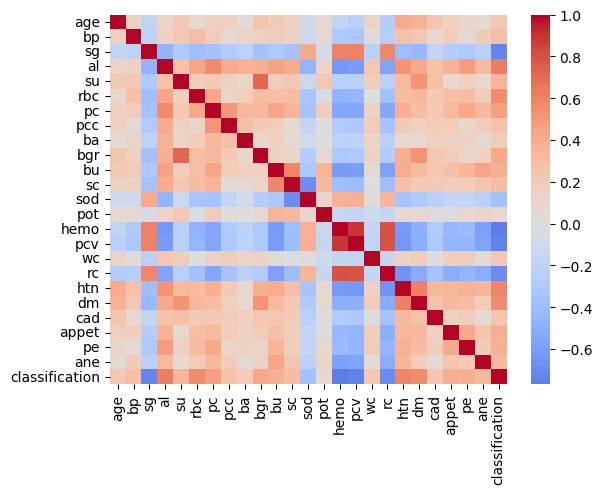

In [328]:
corr = df_corr.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

In [329]:
corr["classification"].abs().sort_values(ascending=False)

classification    1.000000
hemo              0.768919
pcv               0.741427
sg                0.732163
rc                0.699089
al                0.627090
htn               0.588820
dm                0.557444
rbc               0.555097
pc                0.461812
bgr               0.419672
appet             0.392645
bu                0.380605
sod               0.375674
pe                0.374480
su                0.344070
ane               0.324787
sc                0.299969
bp                0.294077
pcc               0.263226
cad               0.235153
wc                0.231919
age               0.227268
ba                0.185345
pot               0.084541
Name: classification, dtype: float64

# Feature Preparation and Train-Test Split

In [330]:
y.isnull().sum()

np.int64(0)

In [331]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [332]:
num_mean_pipeline = Pipeline([
    ("mean_imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

num_median_pipeline = Pipeline([
    ("median_imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

most_frequent_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop='first', handle_unknown="ignore"))
])

constant_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(drop='first', handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("mean", num_mean_pipeline, mean_cols),
    ("median", num_median_pipeline, median_cols),
    ("most_frequent", most_frequent_pipeline, most_frequent_cols),
    ("unknown", constant_pipeline, constant_cols)
])

# Model Definition

In [342]:
models = {
    "LogisticRegression":LogisticRegression(max_iter=1000),
    "DecisionTree":DecisionTreeClassifier(max_depth=10, random_state=42),
    "RandomForest":RandomForestClassifier(n_estimators=50,max_depth=10,random_state=42),
    "SVM":SVC(),
    "GradientBoosting":GradientBoostingClassifier(n_estimators=50,random_state=42),
    "XGBoost":XGBClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
}

# Cross Validation

In [346]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

results = []

for name, model in models.items():

    model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )
    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean()
    })

results_df = pd.DataFrame(results)

display(results_df)


,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,1.000000,1.000000,1.000,1.000000
1,DecisionTree,0.968750,0.966202,0.985,0.975367
2,RandomForest,0.993750,0.990244,1.000,0.995062
3,SVM,1.000000,1.000000,1.000,1.000000
4,GradientBoosting,0.987500,0.985714,0.995,0.990244
5,XGBoost,0.990625,0.990122,0.995,0.992531
6,CatBoost,0.996875,1.000000,0.995,0.997468
